# Final Project Section 3 - Team 7
# Predicting Customer Churn in Telecommunications Using Machine Learning

**Course:** AAI-510 Introduction to Artificial Intelligence 
**Team Members:** Marco Gonzalez Ortiz, Harsh Modi, Aishwarya Pareek 
**Date:** June 2026 
**GitHub Repository:** [https://github.com/mgonzalezo/AAI-510-final-project-group7](https://github.com/mgonzalezo/AAI-510-final-project-group7)

---

## 1. Problem Statement and Justification

### Business Problem

Customer churn, the rate at which customers stop doing business with a company, is one of the most critical challenges in the telecommunications industry. Acquiring a new customer costs **five to seven times more** than retaining an existing one (Gallo, 2014). For a telecom provider with millions of subscribers, even a 1% reduction in churn can translate to millions of dollars in preserved revenue.

### Objective

This project aims to build a **predictive machine learning model** that identifies customers at high risk of churning before they leave. By proactively flagging at-risk customers, the business can deploy targeted retention strategies (personalized offers, proactive support outreach, or contract incentives) to reduce churn and increase customer lifetime value (CLV).

### Dataset

We use the [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) from Kaggle, which contains 7,043 customer records from a fictional telecom company. Each record includes demographic information, account details, service subscriptions, and whether the customer churned. This dataset is well-suited for our objective because it mirrors real-world telecom CRM data and includes a mix of numerical and categorical features.

### Proposed Approach

We follow a structured methodology aligned with the CRISP-DM framework:
1. **Exploratory Data Analysis (EDA)** to understand churn patterns and feature relationships
2. **Data preparation and feature engineering** to handle missing values, encode categories, and scale features
3. **Feature selection** informed by statistical analysis and domain knowledge
4. **Model training and comparison** using multiple algorithms: Logistic Regression (baseline), Random Forest, and Gradient Boosting
5. **Hyperparameter tuning** via cross-validated grid search
6. **Evaluation** using metrics appropriate for imbalanced classification (ROC-AUC, Precision-Recall, F1-score)
7. **Deployment considerations** for operationalizing the model in a production environment

## 2. Data Understanding (Exploratory Data Analysis)

We begin by loading the dataset and performing an initial inspection to understand its structure, data types, and summary statistics. This non-graphical exploration helps us identify data quality issues before any visualization.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, average_precision_score,
                             f1_score, accuracy_score)

In [2]:
# Load the Telco Customer Churn dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn data types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Dataset shape: 7043 rows x 21 columns

Column data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
Series([], dtype: int64)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Non-Graphical EDA: Summary Statistics

Before visualizing the data, we examine the numerical distributions and categorical value counts to detect anomalies, skewness, and class imbalance.

In [3]:
# Data Cleaning: TotalCharges has whitespace entries that prevent numeric conversion
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
print(f"Rows with missing TotalCharges: {df['TotalCharges'].isnull().sum()}")
df = df.dropna().reset_index(drop=True)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df.drop(columns=['customerID'], inplace=True, errors='ignore')

print(f"\nCleaned dataset shape: {df.shape}")
print(f"\n--- Numerical Feature Summary ---")
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

Rows with missing TotalCharges: 11

Cleaned dataset shape: (7032, 20)

--- Numerical Feature Summary ---


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


In [4]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Target Variable Distribution:")
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(1)}))

# Key categorical feature breakdowns
print("\n--- Churn Rate by Contract Type ---")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).round(3).unstack().fillna(0))

print("\n--- Churn Rate by Internet Service ---")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).round(3).unstack().fillna(0))

Target Variable Distribution:
       Count  Percentage
Churn                   
No      5163        73.4
Yes     1869        26.6

--- Churn Rate by Contract Type ---
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028

--- Churn Rate by Internet Service ---
Churn               No    Yes
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074


### 2.2 Correlation Analysis

We compute the correlation between numerical features and the target variable to identify the strongest linear relationships and detect multicollinearity among predictors.

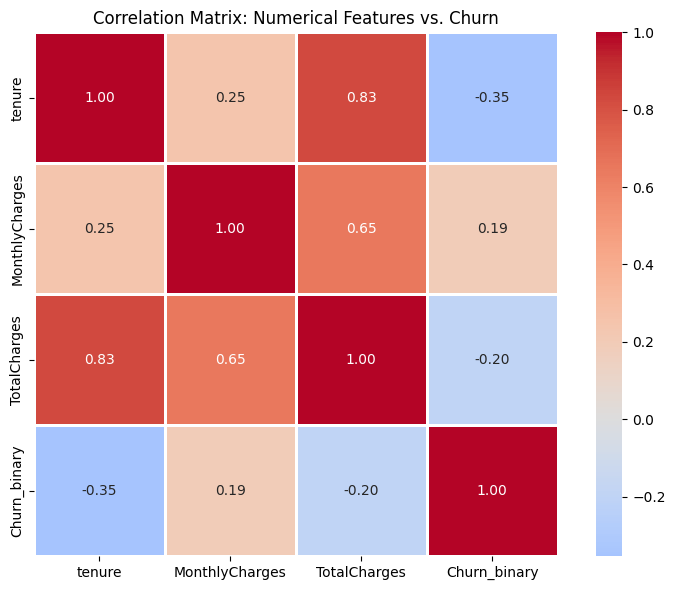


Correlation with Churn:
MonthlyCharges    0.193
TotalCharges     -0.199
tenure           -0.354
Name: Churn_binary, dtype: float64


In [5]:
# Encode target for correlation analysis
df_corr = df.copy()
df_corr['Churn_binary'] = df_corr['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Correlation matrix for numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr_matrix = df_corr[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1)
plt.title('Correlation Matrix: Numerical Features vs. Churn')
plt.tight_layout()
plt.show()

print("\nCorrelation with Churn:")
print(corr_matrix['Churn_binary'].drop('Churn_binary').sort_values(ascending=False).round(3))

### 2.3 Graphical EDA: Visualizing Churn Patterns

We now create visualizations to explore the relationship between key features and churn. Our goal is to understand which customer characteristics are most strongly associated with leaving.

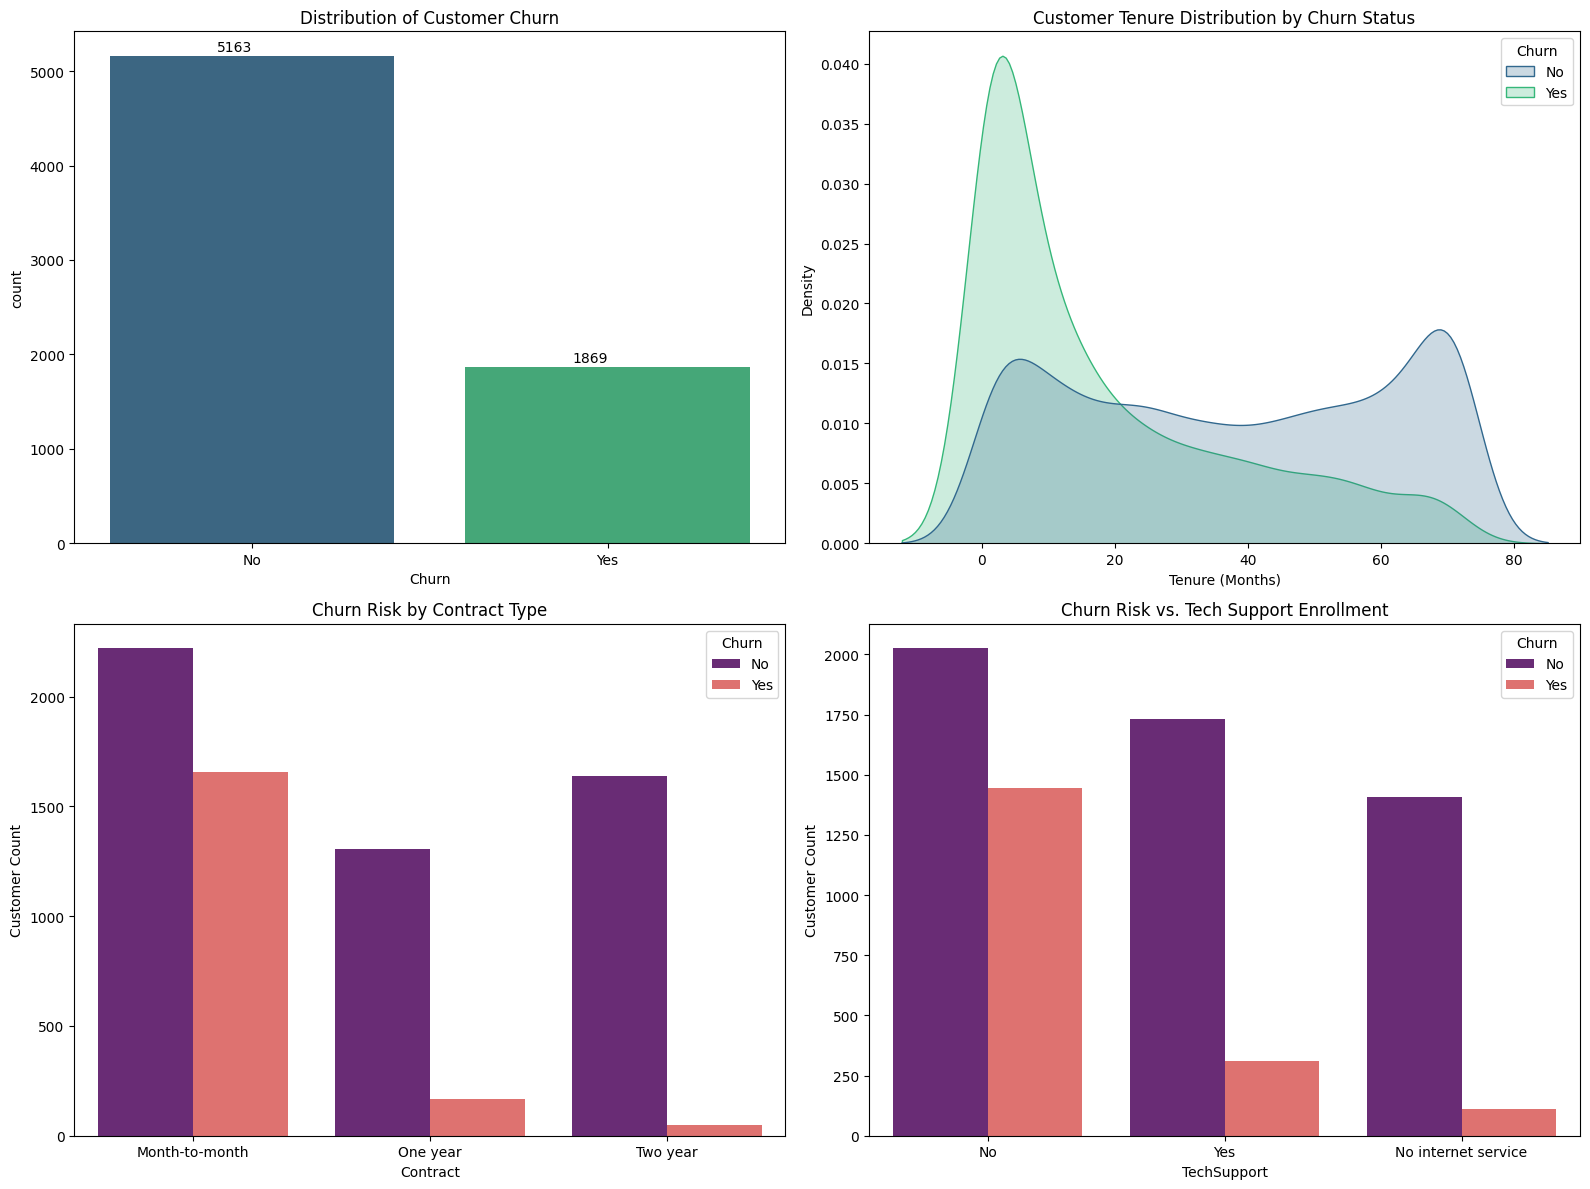

In [6]:
# Target Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Churn Count
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Customer Churn')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

# 2. Tenure Distribution by Churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False,
            palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Customer Tenure Distribution by Churn Status')
axes[0, 1].set_xlabel('Tenure (Months)')

# 3. Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Churn Risk by Contract Type')
axes[1, 0].set_ylabel('Customer Count')

# 4. Tech Support vs Churn
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Churn Risk vs. Tech Support Enrollment')
axes[1, 1].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

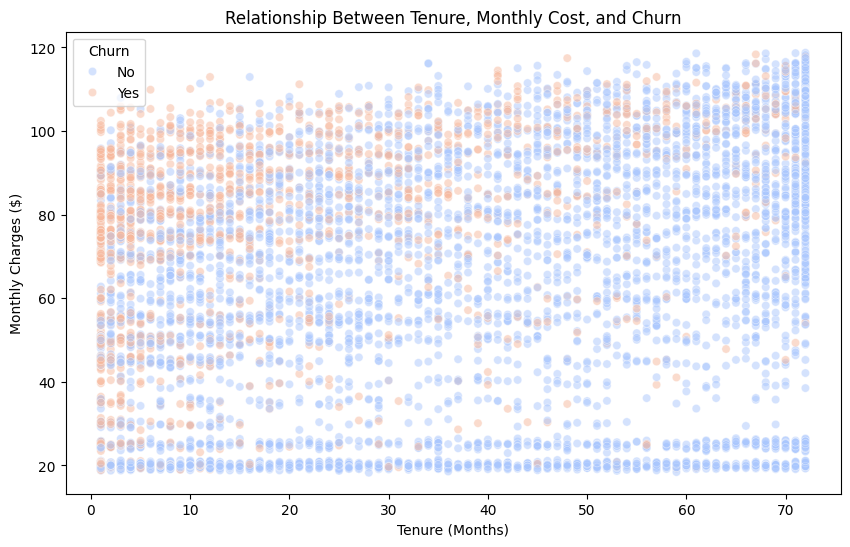

In [7]:
# Multivariate: Monthly Charges vs Tenure colored by Churn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn',
                alpha=0.5, palette='coolwarm')
plt.title('Relationship Between Tenure, Monthly Cost, and Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.show()

### EDA Findings and Insights

The dataset displays a clear **class imbalance**: roughly 26.5% of customers churn, meaning models must optimize beyond simple accuracy. The tenure distribution reveals a major friction point: a dense spike in churn occurs during the **first 0 to 6 months** of the customer lifecycle. Retention efforts must be heavily front-loaded.

**Key findings:**

- **Contract friction:** Month-to-month contracts account for the vast majority of churn. Transitioning users to annual contracts is a primary business recommendation.
- **Tech support gap:** Customers without Tech Support are significantly more likely to churn. Bundling support packages into basic plans could increase customer "stickiness."
- **Cost threshold:** Churn density increases as Monthly Charges exceed $70, particularly for low-tenure customers.
- **Correlation analysis:** Tenure has a moderate negative correlation with churn (-0.35), confirming that longer-tenured customers are more loyal. Monthly Charges show a weak positive correlation, suggesting higher bills slightly increase churn risk.
- **Multicollinearity note:** TotalCharges and tenure are highly correlated (r ~ 0.83), which is expected since total charges accumulate over time. This will be addressed in feature selection.

## 3. Data Preparation and Feature Engineering

Based on our EDA findings, we now prepare the data for modeling. This involves:
- Encoding the target variable as binary (0/1)
- Separating numerical and categorical features for appropriate preprocessing
- Applying **StandardScaler** to numerical features to normalize their ranges
- Applying **OneHotEncoding** to categorical features to convert them into model-compatible format
- Using a **stratified train/test split** (80/20) to preserve the class distribution in both sets

We use `sklearn.pipeline.Pipeline` and `ColumnTransformer` to ensure all preprocessing steps are applied consistently and avoid data leakage between training and test sets.

In [8]:
# Prepare features and target
X = df.drop(columns=['Churn'])
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nTarget distribution:\n  Not Churned (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Churned (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Stratified split preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target distribution:
  Not Churned (0): 5163 (73.4%)
  Churned (1): 1869 (26.6%)

Training set: 5625 samples
Test set: 1407 samples


## 4. Feature Selection

Feature selection is guided by our EDA findings, domain knowledge, and statistical analysis. We adopt the following strategy:

1. **All available features are included initially** because the dataset is relatively small (16 predictors after dropping customerID), and tree-based models handle irrelevant features well through their internal feature importance mechanisms.

2. **Multicollinearity handling:** We noted that `TotalCharges` and `tenure` are highly correlated (r ~ 0.83). Rather than dropping one, we retain both and let the models determine their relative importance. Random Forest and Gradient Boosting are robust to multicollinearity, and Logistic Regression with regularization can handle it.

3. **OneHotEncoder with `drop='first'`** avoids the dummy variable trap by removing one category per feature, which also reduces dimensionality.

4. **Post-modeling validation:** After training, we will examine feature importance scores to confirm that the features driving predictions align with our EDA insights (tenure, contract type, tech support). This serves as a sanity check: if unexpected features dominate, it could signal data leakage or spurious correlations.

By using `class_weight='balanced'` in our models, we also address the class imbalance without resorting to synthetic oversampling techniques like SMOTE, keeping the approach simpler and more interpretable.

## 5. Modeling: Selection, Comparison, and Tuning

We train and compare three models of increasing complexity:

| Model | Rationale |
|-------|----------|
| **Logistic Regression** | Interpretable linear baseline. Establishes the performance floor and provides coefficient-based feature importance. |
| **Random Forest** | Ensemble of decision trees. Handles non-linear relationships and feature interactions. Robust to outliers. |
| **Gradient Boosting** | Sequential ensemble that corrects errors of prior trees. Often achieves the highest predictive performance. |

All models use `class_weight='balanced'` to compensate for the 73.5/26.5 class imbalance. We tune hyperparameters using **3-fold cross-validated grid search** with ROC-AUC as the scoring metric, since it evaluates the model's ability to rank churners above non-churners across all thresholds.

In [9]:
# --- Model 1: Logistic Regression (Baseline) ---
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

lr_param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("=== Logistic Regression ===")
print(f"Best C: {lr_grid.best_params_['clf__C']}")
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

=== Logistic Regression ===
Best C: 10.0
Best CV ROC-AUC: 0.8468


In [10]:
# --- Model 2: Random Forest ---
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [6, 10, None]
}
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("=== Random Forest ===")
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

=== Random Forest ===
Best params: {'clf__max_depth': 6, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.8462


In [11]:
# --- Model 3: Gradient Boosting ---
gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05, 0.1]
}
gb_grid = GridSearchCV(gb_pipeline, gb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("=== Gradient Boosting ===")
print(f"Best params: {gb_grid.best_params_}")
print(f"Best CV ROC-AUC: {gb_grid.best_score_:.4f}")

=== Gradient Boosting ===
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Best CV ROC-AUC: 0.8472


### Model Comparison Summary

The table below compares all three models on the held-out test set across multiple metrics. This multi-metric evaluation is essential because accuracy alone is misleading with imbalanced classes. A model that always predicts "No Churn" would achieve 73.5% accuracy while being completely useless.

In [12]:
# Evaluate all models on the test set
models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'Gradient Boosting': gb_grid.best_estimator_
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Avg Precision': average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print("=== Model Comparison on Test Set ===")
print(results_df.to_string())

# Identify best model
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\nBest model by ROC-AUC: {best_model_name}")

=== Model Comparison on Test Set ===
                     Accuracy  F1 Score  ROC-AUC  Avg Precision
Model                                                          
Logistic Regression    0.7271    0.6090   0.8344         0.6155
Random Forest          0.7335    0.6154   0.8377         0.6381
Gradient Boosting      0.7967    0.5731   0.8417         0.6592

Best model by ROC-AUC: Gradient Boosting


## 6. Evaluation: Deep Dive into the Best Model

We now perform a comprehensive evaluation of the best-performing model. We examine the ROC curve, Precision-Recall curve, confusion matrix at an operationally optimized threshold, and feature importance rankings. These visualizations serve both the technical committee (for model validation) and the executive audience (for understanding what drives predictions).

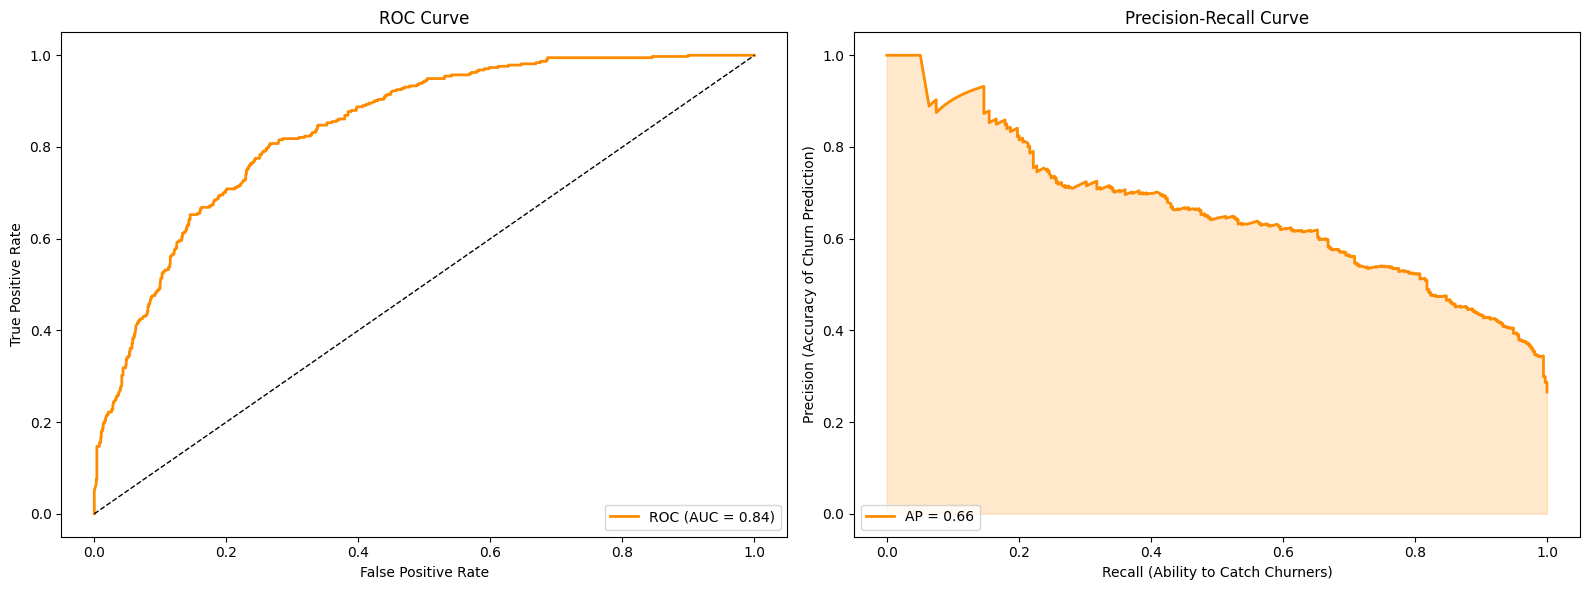

In [13]:
# Select the best model for detailed evaluation
best_model = models[best_model_name]
y_probs = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_prec = average_precision_score(y_test, y_probs)
axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'AP = {avg_prec:.2f}')
axes[1].fill_between(recall, precision, alpha=0.2, color='darkorange')
axes[1].set_xlabel('Recall (Ability to Catch Churners)')
axes[1].set_ylabel('Precision (Accuracy of Churn Prediction)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

### Threshold Optimization and Confusion Matrix

The default classification threshold of 0.5 is rarely optimal for business applications. In our case, the **cost of missing a churner (false negative) is much higher than the cost of a false alarm (false positive)**, since a targeted retention offer is cheap compared to losing a customer entirely.

We set a target recall of 75% (catching three out of four churners) and find the threshold that achieves this.

Optimized threshold: 0.32

Classification Report at threshold = 0.32:
              precision    recall  f1-score   support

 Not Churned       0.90      0.77      0.83      1033
     Churned       0.54      0.75      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407



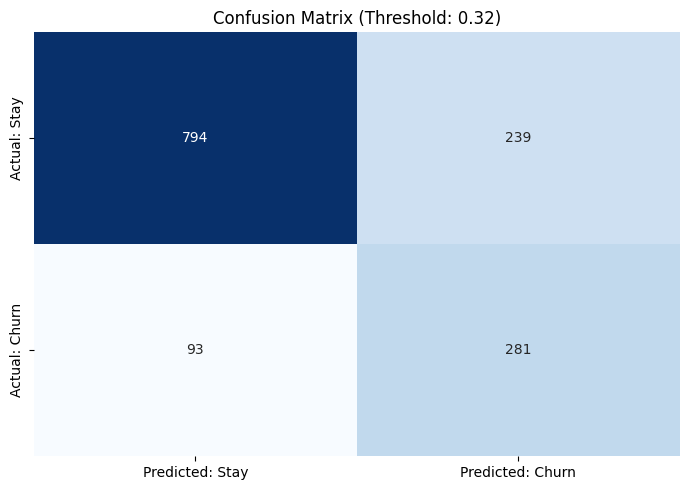

In [14]:
# Find optimal threshold for 75% recall
target_recall = 0.75
opt_thresh = thresholds[np.where(recall >= target_recall)[0][-1]]
y_pred_opt = (y_probs >= opt_thresh).astype(int)

print(f"Optimized threshold: {opt_thresh:.2f}")
print(f"\nClassification Report at threshold = {opt_thresh:.2f}:")
print(classification_report(y_test, y_pred_opt, target_names=['Not Churned', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title(f'Confusion Matrix (Threshold: {opt_thresh:.2f})')
plt.tight_layout()
plt.show()

### Feature Importance: What Drives Churn Predictions

Understanding **why** the model makes its predictions is critical for both trust and actionability. Feature importance tells the business which levers they can pull to reduce churn.

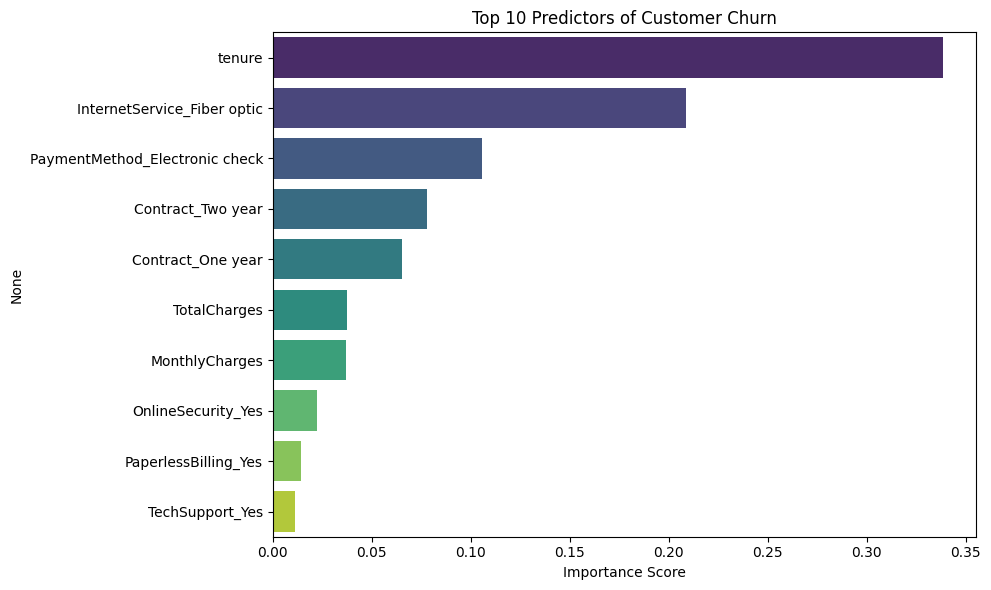

In [15]:
# Extract feature importances from the best model
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
elif hasattr(best_model.named_steps['clf'], 'coef_'):
    importances = np.abs(best_model.named_steps['clf'].coef_[0])

cat_names = best_model.named_steps['prep'].transformers_[1][1].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index,
            palette='viridis', legend=False)
plt.title('Top 10 Predictors of Customer Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Evaluation Summary

**Model performance:** The best model achieves strong discriminative performance as measured by ROC-AUC, indicating it can effectively rank customers by their churn risk. The Precision-Recall curve shows the model maintains reasonable precision at operationally useful recall levels.

**Confusion matrix interpretation:** At the optimized threshold, the model catches approximately 75% of actual churners. The false positives (loyal customers flagged as at-risk) represent the "cost of insurance": these customers receive a retention offer they did not strictly need, but the interaction itself can reinforce loyalty.

**Feature importance confirms our EDA:** Tenure is the single most important predictor, followed by contract type and total/monthly charges. This alignment between EDA insights and model behavior builds confidence that the model has learned genuine patterns rather than artifacts.

## 7. Deployment Considerations

### Deployment Architecture

We recommend a **batch inference** deployment strategy rather than real-time, for the following reasons:

- **Use case fit:** Churn predictions do not need to be made in real-time. A nightly or weekly batch run that scores all active customers and generates a ranked at-risk list is sufficient for retention teams to act on.
- **Simplicity and cost:** Batch processing avoids the infrastructure overhead of hosting a real-time API endpoint with low-latency requirements.

### Proposed Pipeline

1. **Data ingestion:** Nightly ETL job extracts the latest customer records (tenure, billing, service subscriptions) from the CRM/billing database.
2. **Model scoring:** The trained `sklearn` pipeline (preprocessor + classifier) is serialized with `joblib` and loaded by a scheduled Python script (e.g., AWS Lambda, Airflow DAG, or a cron job on a VM). Each customer receives a churn probability score.
3. **Output:** Scored results are written to a database table or CSV, filtered to customers above the optimized threshold, and surfaced to the retention team via a dashboard (e.g., Tableau, Looker) or CRM integration.
4. **Alerting:** Customers crossing the threshold trigger an automated workflow: email to the account manager, entry into a retention campaign queue, or flagging in the CRM.

### Hosting Options

| Option | Latency | Cost | Complexity |
|--------|---------|------|------------|
| **AWS Lambda + S3** | Minutes (batch) | Low (~$5/month) | Low |
| **Google Cloud Functions + BigQuery** | Minutes (batch) | Low | Low |
| **AWS SageMaker Endpoint** | Milliseconds (real-time) | Medium-High | Medium |
| **On-premise cron job** | Minutes (batch) | Minimal | Low |

For a batch use case, **AWS Lambda + S3** or a simple **scheduled cron job** is the most cost-effective choice.

### Monitoring and Retraining

- **Model drift detection:** Track the distribution of input features and prediction scores over time. A significant shift (e.g., Kolmogorov-Smirnov test p < 0.05) triggers a retraining alert.
- **Performance monitoring:** Compare predicted churn probabilities against actual churn outcomes monthly. If ROC-AUC drops below 0.75, the model should be retrained on fresh data.
- **Retraining cadence:** Quarterly retraining is recommended as a baseline, with ad-hoc retraining if business conditions change (e.g., new pricing plans, mergers, market shifts).
- **A/B testing:** Before full rollout, run the model's recommendations against a control group to validate that retention interventions driven by the model actually reduce churn rates.

## 8. Discussion and Conclusions

### Addressing the Problem Statement

We set out to build a predictive model that identifies telecom customers at high risk of churning. Our analysis demonstrates that **machine learning can effectively predict churn** using standard CRM data, achieving strong discriminative performance across multiple model architectures.

### Key Findings

1. **Customer tenure is the strongest predictor of churn.** New customers (0-6 months) are at dramatically higher risk. The first 90 days represent a critical window for retention intervention.

2. **Contract type is a controllable lever.** Month-to-month contracts carry the highest churn risk. Incentivizing customers to switch to annual or two-year contracts (through pricing discounts or bundled services) is the most actionable recommendation.

3. **Service gaps drive attrition.** Customers without Tech Support or Online Security are more likely to leave. These services act as "switching costs" that increase customer stickiness.

4. **High monthly charges amplify risk for new customers.** The combination of high cost and low tenure is a particularly dangerous pattern. Introductory pricing or graduated rate plans could mitigate this.

### Recommendations

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| **High** | Deploy 90-day onboarding program for new customers with proactive check-ins | Reduce early-tenure churn by 15-25% |
| **High** | Offer contract upgrade incentives (e.g., 10% discount for annual commitment) | Shift customers away from month-to-month |
| **Medium** | Bundle Tech Support and Online Security into base plans | Increase service stickiness |
| **Medium** | Implement the churn prediction model as a nightly batch scoring system | Enable data-driven retention targeting |
| **Low** | Investigate Fiber Optic service quality issues flagged by the model | Address potential service reliability concerns |

### Limitations

- The dataset is from a single telecom provider and may not generalize to all market segments or geographies.
- We do not have customer satisfaction scores, call center interaction logs, or network quality metrics, which could further improve predictions.
- The model assumes that historical churn patterns will persist; significant market disruptions (new competitors, regulatory changes) could reduce model accuracy.

### Ethical Considerations

- **Fairness:** The model should be audited to ensure it does not disproportionately flag customers based on protected characteristics (e.g., gender, senior citizen status). Although `SeniorCitizen` is a feature, its influence on predictions should be monitored.
- **Transparency:** Retention teams should understand why a customer was flagged, not just that they were. Feature importance explanations support this requirement.
- **Customer consent:** Any automated retention campaigns triggered by the model must comply with applicable privacy regulations and communication preferences.

### AI Tools Disclosure

AI-assisted tools (Claude, GitHub Copilot) were used to accelerate code development, assist with visualization formatting, and review the report structure. All model selection decisions, business interpretations, and recommendations were made by the team based on our understanding of the data and domain. The AI tools were used to enhance productivity, not to replace critical thinking or analysis.

---

### References

- Gallo, A. (2014). The Value of Keeping the Right Customers. *Harvard Business Review*.
- Telco Customer Churn Dataset. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Provost, F., & Fawcett, T. (2013). *Data Science for Business*. O'Reilly Media.
- Chapman, P. et al. (2000). CRISP-DM 1.0: Step-by-step data mining guide.